# Лабораторная №2 курса "Синтез Речи"

## Импорты и константы

In [452]:
import csv
from collections import Counter
from pathlib import Path
import random
import re

import jenkspy
import librosa
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from praatio import textgrid
from pprint import pp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from torch import Tensor
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [274]:
SR = 16000
RANDOM_SEED = 42

In [275]:
RUSLAN_AUDIO_PATH = Path("../../data/RUSLAN/")
RUSLAN_TG_PATH = Path("data/RUSLAN_22050_align_v2/")
RUSLAN_METADATA_PATH = Path("../../data/metadata_RUSLAN_22200_normalized.csv")
RUSLAN_PAUSE_METADATA_PATH = Path("data/RUSLAN_pause_metadata.csv")

In [276]:
def read_tg(tg_path):
    return textgrid.openTextgrid(str(tg_path), includeEmptyIntervals=False)

In [277]:
test_tg_path = RUSLAN_TG_PATH / "000000_RUSLAN.TextGrid"

In [278]:
test_tg = read_tg(test_tg_path)
print(test_tg.tierNames)

('words', 'phones')


## EDA

### Превращаем TextGrid в последовательности для уровней слов и фонем

Намеренно не добавляем начальные паузы (если вдруг есть, но при осмотре не заметил) и конечные, потому что, после прослушивания, появилось убеждение, что паузы между записями не равны реальным паузам между фразами, которые были в оригинальном прочтении

In [279]:
def get_corp_sequence(tier):
    interval_start_end_list = [
        [interval.start, interval.end, interval.label] 
        for interval in tier
    ]

    seq_list = []
    for interval1, interval2 in zip(
        interval_start_end_list[:-1], interval_start_end_list[1:]
    ):

        # Основной интервал
        seq_list.append([interval1[0], interval1[1], interval1[2]])
        # Детектируем паузы
        if interval1[1] != interval2[0]:
            seq_list.append(
                [interval1[1], interval2[0], ""]
            )
            
    return seq_list

In [280]:
words = []
phones = []
for root, dirs, files in RUSLAN_TG_PATH.walk():
    file_words_list = []
    for file in files:
        file = Path(file)
        path = root / file
        file_id = file.with_suffix("")

        tg = read_tg(path)
        words_tier = tg.getTier("words")
        phones_tier = tg.getTier("phones")

        for word in get_corp_sequence(words_tier):
            # file_id, start, end, duration, label
            words.append(
                [file_id, word[0], word[1], word[1] - word[0], word[2]]
            )

        for phone in get_corp_sequence(phones_tier):
            # file_id, start, end, duration, label
            phones.append(
                [file_id, phone[0], phone[1], phone[1] - phone[0], phone[2]]
            )

In [281]:
eda_columns = ["file_id", "start", "end", "duration", "label"]

words_df = pd.DataFrame(words, columns=eda_columns)
phones_df = pd.DataFrame(phones, columns=eda_columns)

In [282]:
print(words_df.head())
print()
print(phones_df.head())
print()

         file_id  start   end  duration    label
0  021362_RUSLAN   0.00  0.33      0.33    можно
1  021362_RUSLAN   0.33  0.64      0.31   делать
2  021362_RUSLAN   0.64  1.03      0.39     фото
3  021362_RUSLAN   1.03  1.16      0.13       на
4  021362_RUSLAN   1.16  1.52      0.36  обычном

         file_id  start   end  duration label
0  021362_RUSLAN   0.00  0.03      0.03     m
1  021362_RUSLAN   0.03  0.14      0.11     o
2  021362_RUSLAN   0.14  0.22      0.08     ʐ
3  021362_RUSLAN   0.22  0.28      0.06    n̪
4  021362_RUSLAN   0.28  0.33      0.05     ə



In [283]:
pauses_df = words_df[words_df["label"] == ""]
print(pauses_df.head())

          file_id  start   end  duration label
6   021362_RUSLAN   2.03  2.67      0.64      
8   021362_RUSLAN   3.07  3.10      0.03      
10  021362_RUSLAN   3.71  3.91      0.20      
12  021362_RUSLAN   4.35  4.47      0.12      
20  019307_RUSLAN   2.64  2.72      0.08      


### Mean & std

In [284]:
print(f"Средняя длина паузы: {pauses_df['duration'].mean():.2f}")
print(f"Средняя длина слова: {words_df['duration'].mean():.2f}")
print(f"Средняя длина фонемы: {phones_df['duration'].mean():.2f}")

Средняя длина паузы: 0.16
Средняя длина слова: 0.36
Средняя длина фонемы: 0.08


In [285]:
print(f"std длины паузы: {pauses_df['duration'].std():.2f}")
print(f"std длины слова: {words_df['duration'].std():.2f}")
print(f"std длины фонемы: {phones_df['duration'].std():.2f}")

std длины паузы: 0.15
std длины слова: 0.23
std длины фонемы: 0.06


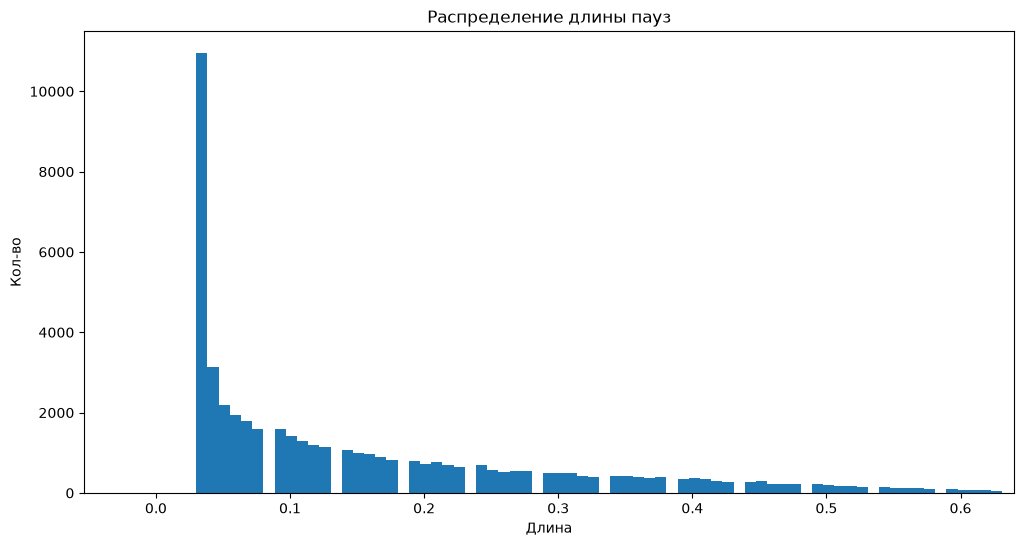

In [286]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длина")
plt.ylabel("Кол-во")
plt.hist(pauses_df['duration'], bins=200)
plt.xlim(right=np.quantile(pauses_df['duration'], 0.99))
plt.title("Распределение длины пауз")
plt.show()

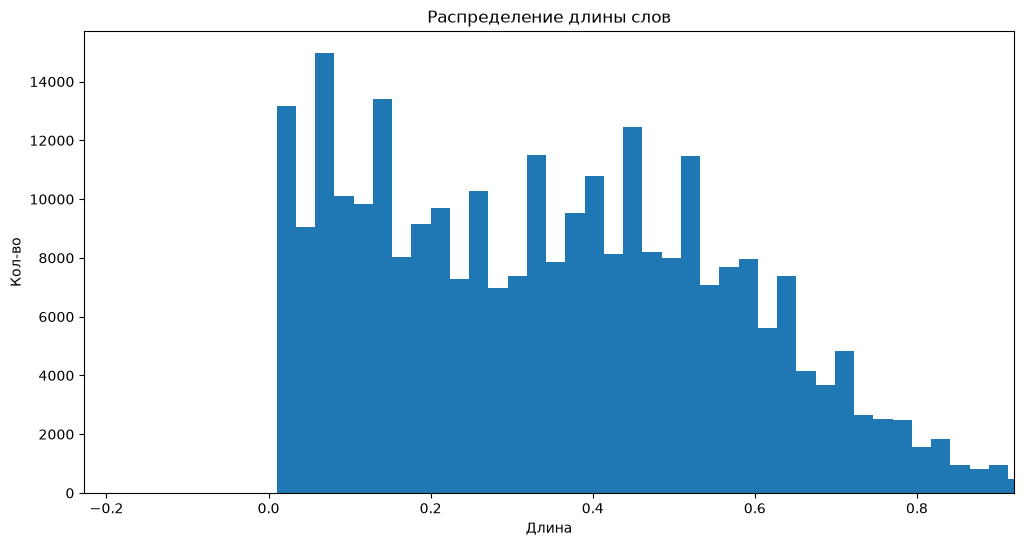

In [287]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длина")
plt.ylabel("Кол-во")
plt.hist(words_df['duration'], bins=200)
plt.xlim(right=np.quantile(words_df['duration'], 0.99))
plt.title("Распределение длины слов")
plt.show()

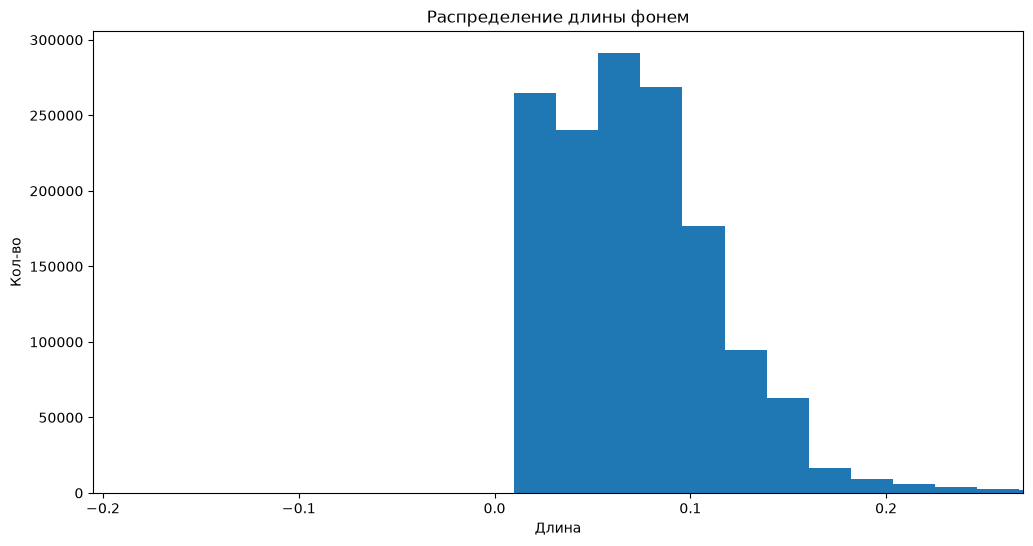

In [288]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длина")
plt.ylabel("Кол-во")
plt.hist(phones_df['duration'], bins=200)
plt.xlim(right=np.quantile(phones_df['duration'], 0.99))
plt.title("Распределение длины фонем")
plt.show()

In [289]:
phonemes = set(phones_df["label"].to_list())
vowels = {"æ", "ɐ", "ə", "ɛ", "ɨ", "ɪ", "ɵ", "ʉ", "ʊ"}

In [290]:
phones_vowels_df = phones_df[phones_df["label"].isin(vowels)]
print(phones_vowels_df.head())

          file_id  start   end  duration label
4   021362_RUSLAN   0.28  0.33      0.05     ə
8   021362_RUSLAN   0.56  0.61      0.05     ə
13  021362_RUSLAN   0.98  1.03      0.05     ə
15  021362_RUSLAN   1.10  1.16      0.06     ə
16  021362_RUSLAN   1.16  1.20      0.04     ɐ


In [291]:
print(f"Средняя длина гласной: {phones_vowels_df['duration'].mean():.2f}")
print(f"std длины гласной: {phones_vowels_df['duration'].std():.2f}")

Средняя длина гласной: 0.04
std длины гласной: 0.05


### Предпаузальное удлиннение

In [292]:
word_pauses_idxs = words_df[words_df["label"] == ""].index
phone_pauses_idxs = phones_df[phones_df["label"] == ""].index

In [293]:
words_before_pauses = words_df.iloc[word_pauses_idxs - 1]
print(words_before_pauses.head())

          file_id  start   end  duration     label
5   021362_RUSLAN   1.52  2.03      0.51   картоне
7   021362_RUSLAN   2.67  3.07      0.40     генис
9   021362_RUSLAN   3.10  3.71      0.61  изумился
11  021362_RUSLAN   3.91  4.35      0.44       как
19  019307_RUSLAN   2.12  2.64      0.52     книги


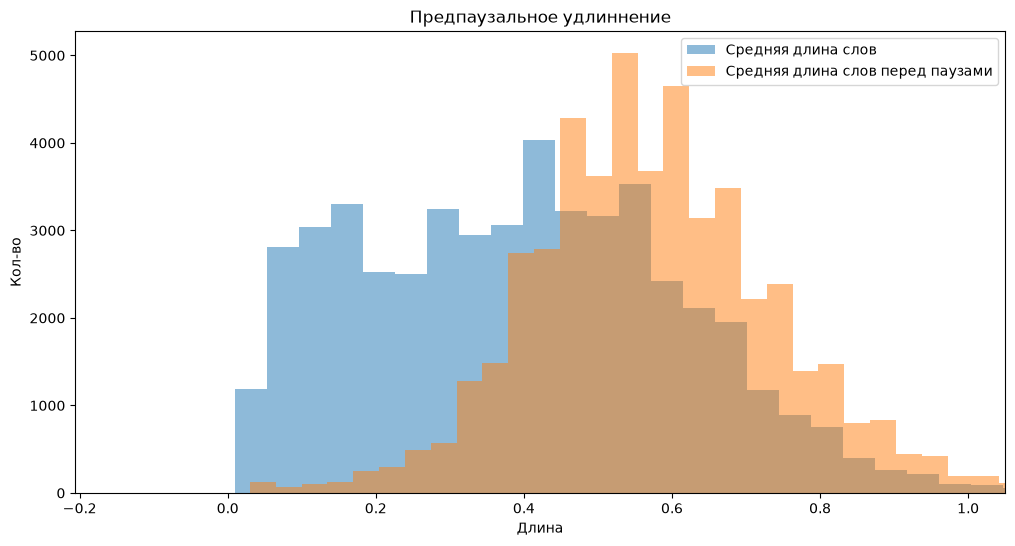

In [294]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длина")
plt.ylabel("Кол-во")
plt.hist(
    words_df[words_df["label"] != ""]['duration'].sample(
        len(words_before_pauses), random_state=RANDOM_SEED
    ), 
    bins=100, 
    label="Средняя длина слов",
    alpha=0.5
)
plt.hist(
    words_before_pauses['duration'], 
    bins=100, 
    label="Средняя длина слов перед паузами",
    alpha=0.5
)
plt.legend()
plt.xlim(right=np.quantile(words_before_pauses['duration'], 0.99))
plt.title("Предпаузальное удлиннение")
plt.show()

### Jenks Natural Breaks Optimization

In [295]:
pause_length_breaks = jenkspy.jenks_breaks(
    pauses_df["duration"].to_list(),
    n_classes=3
)
print(list(map(float, pause_length_breaks)))

[0.02999799999999908, 0.15000200000000063, 0.36000100000000046, 1.6999999999999997]


Классификация пауз по ЛФШ:

* короткая – около 0,1–0,3 с;
* средняя – около 0,3–0,7 с;
* длинная – более 0,7 с.

Нельзя сказать, что наши классы идеально разделились по этим группам:

* короткая – до 0,15;
* средняя – от 0,15 до 0,36;
* короткая – от 0,36 до 1,7.

### Голос в паузах по RMS

In [296]:
pauses_rms = []
for row in pauses_df.iterrows():
    audio_path = RUSLAN_AUDIO_PATH / Path(row[1]["file_id"]).with_suffix(".wav")
    audio, _ = librosa.load(audio_path, sr=SR)

    pause_start_sample = int(row[1]["start"] * SR)
    pause_end_sample = int(row[1]["end"] * SR)
    pause = audio[pause_start_sample:pause_end_sample]

    pauses_rms.append(librosa.feature.rms(y=pause).mean())

In [297]:
pauses_df["rms"] = pauses_rms

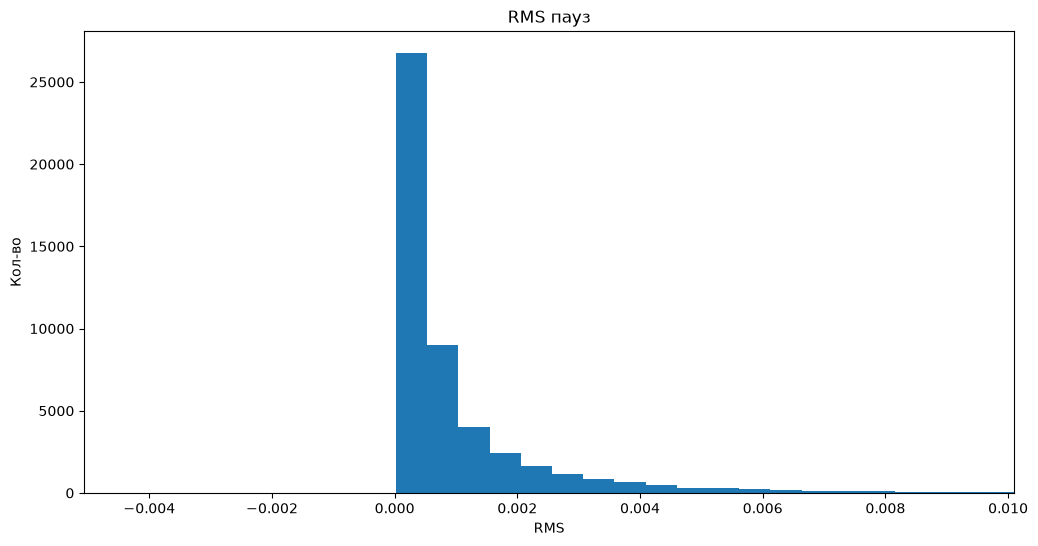

In [298]:
plt.figure(figsize=(12, 6))
plt.xlabel("RMS")
plt.ylabel("Кол-во")
plt.hist(
    pauses_df["rms"], 
    bins=200,
)
plt.xlim(right=np.quantile(pauses_df["rms"], 0.99))
plt.title("RMS пауз")
plt.show()

## Подготовка данных

Совместим текст из метаданных с интервалами слов из TextGrid. Пунктуацию добавим к предыдущему слову, а информацию о паузах сохраним в `is_pause_after` и `pause_duration`

In [299]:
def normalize_text(text):
    text = text.replace("‐", "-").replace("‑", "-").replace("’", "'")
    return re.sub(r"\([^)]*\)|<[^>]*>", "[bracketed]", text)


def get_raw_labels(labels, text):
    raw_labels = []
    text_lower = text.lower()

    for label in labels:
        parts = text_lower.split(label, maxsplit=1)
        if len(parts) != 2:
            return None

        prefix_length = len(parts[0])
        if raw_labels:
            raw_labels[-1] += text[:prefix_length].strip()
            raw_labels.append(text[prefix_length:prefix_length + len(label)])
        else:
            raw_labels.append(text[:prefix_length + len(label)].strip())

        consumed = prefix_length + len(label)
        text = text[consumed:]
        text_lower = parts[1]

    if raw_labels:
        raw_labels[-1] += text.strip()
    return raw_labels


def prepare_utterance(wave_id, normalized_text):
    tg_path = RUSLAN_TG_PATH / f"{wave_id}.TextGrid"
    if not tg_path.exists():
        return None

    tg = textgrid.openTextgrid(str(tg_path), includeEmptyIntervals=True)
    word_tier = tg.getTier("words")
    if not isinstance(word_tier, textgrid.IntervalTier):
        return None
    intervals = word_tier.entries
    labels = [normalize_text(interval.label) for interval in intervals]
    word_labels = [label for label in labels if label]
    raw_labels = get_raw_labels(word_labels, normalize_text(normalized_text))
    if raw_labels is None:
        return None

    rows = []
    word_index = -1
    for interval, label in zip(intervals, labels):
        duration = float(interval.end - interval.start)
        if label:
            word_index += 1
            rows.append({
                "id": wave_id,
                "label": label,
                "label_raw": raw_labels[word_index],
                "duration": duration,
                "is_last_word": 0,
                "is_pause_after": 0,
                "pause_duration": 0.0,
            })
        elif rows:
            rows[-1]["is_pause_after"] = 1
            rows[-1]["pause_duration"] += duration

    if not rows:
        return None
    rows[-1]["is_last_word"] = 1
    return rows

In [300]:
ruslan_metadata = pd.read_csv(
    RUSLAN_METADATA_PATH,
    sep="|",
    names=["id", "raw", "nrm"],
    dtype=str,
    quoting=csv.QUOTE_NONE,
    keep_default_na=False,
)

pause_rows = []
skipped = 0
for wave_id, normalized_text in ruslan_metadata[["id", "nrm"]].itertuples(index=False):
    utterance_rows = prepare_utterance(wave_id, normalized_text)
    if utterance_rows is None:
        skipped += 1
        continue
    pause_rows.extend(utterance_rows)

pause_metadata = pd.DataFrame(pause_rows)
pause_metadata = pause_metadata[[
    "id", "label", "label_raw", "duration",
    "is_last_word", "is_pause_after", "pause_duration",
]]

In [301]:
RUSLAN_PAUSE_METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
pause_metadata.to_csv(
    RUSLAN_PAUSE_METADATA_PATH, sep="|", index=False
)

print(f"Строк: {len(pause_metadata):,}")
print(f"Предложений: {pause_metadata['id'].nunique():,}")
print(f"Пропущено предложений: {skipped}")
print(pause_metadata.head())

Строк: 250,688
Предложений: 21,754
Пропущено предложений: 1
              id      label  label_raw  duration  is_last_word  \
0  000000_RUSLAN          с          С      0.11             0   
1  000000_RUSLAN  тревожным  тревожным      0.58             0   
2  000000_RUSLAN   чувством   чувством      0.62             0   
3  000000_RUSLAN     берусь     берусь      0.39             0   
4  000000_RUSLAN          я          я      0.09             0   

   is_pause_after  pause_duration  
0               0             0.0  
1               0             0.0  
2               0             0.0  
3               0             0.0  
4               0             0.0  


## Предиктор пауз

### Feature вектора

In [439]:
pause_metadata

,id,label,label_raw,duration,is_last_word,is_pause_after,pause_duration
0,000000_RUSLAN,с,С,0.11,0,0,0.000000
1,000000_RUSLAN,тревожным,тревожным,0.58,0,0,0.000000
2,000000_RUSLAN,чувством,чувством,0.62,0,0,0.000000
3,000000_RUSLAN,берусь,берусь,0.39,0,0,0.000000
4,000000_RUSLAN,я,я,0.09,0,0,0.000000
...,...,...,...,...,...,...,...
250683,022199_RUSLAN,он,Он,0.19,0,0,0.000000
250684,022199_RUSLAN,тоже,тоже,0.29,0,0,0.000000
250685,022199_RUSLAN,пытается,пытается,0.62,0,0,0.000000
250686,022199_RUSLAN,достичь,достичь,0.41,0,0,0.000000


In [440]:
def get_features(row):
    text = row["label_raw"]
    punctuation_list = [".", ":", ";", "(", ")", ",", "?", "!"]

    char_len = len(text)

    punct_count = sum([1 for _ in punctuation_list if _ in text])

    duration = row["duration"]

    is_last_word = row["is_last_word"]

    return [
        char_len,
        punct_count,
        duration,
        is_last_word
    ]

In [441]:
features = []
for row in pause_metadata.iterrows():
    feats = get_features(row[1])
    features.append(
        feats
    )
y = pause_metadata["is_pause_after"].to_list()

In [442]:
features[0]

[1, 0, 0.11, 0]

In [443]:
features_train, features_test, y_train, y_test = train_test_split(
    features, y, random_state=RANDOM_SEED, test_size=0.2
)

In [444]:
scaler = StandardScaler()
scaler.fit_transform(features_train)
scaler.transform(features_test)

array([[-0.87615047, -0.54194699, -1.26244239, -0.3075091 ],
       [ 0.58707955, -0.54194699,  0.99287267, -0.3075091 ],
       [ 0.00178754, -0.54194699,  0.18095925, -0.3075091 ],
       ...,
       [-0.87615047, -0.54194699, -0.94669828, -0.3075091 ],
       [-0.29085846, -0.54194699, -0.49563527, -0.3075091 ],
       [ 0.29443354, -0.54194699,  0.31627815, -0.3075091 ]],
      shape=(50138, 4))

In [449]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_SEED),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(features_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

In [450]:
preds = logreg_model.predict(features_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89     38072
           1       0.62      0.80      0.70     12066

    accuracy                           0.84     50138
   macro avg       0.78      0.82      0.79     50138
weighted avg       0.86      0.84      0.84     50138



### Эмбеддинги

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    'intfloat/multilingual-e5-large',
    )
model = AutoModel.from_pretrained(
    'intfloat/multilingual-e5-large',
    torch_dtype=torch.float16,
    ).to(device)

'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-large/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-large/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-large/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-large/resolve/main/config.json
Retrying in 8s [Retry 4/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-large/resolve/main/config.json
Retrying in 8s [Retry 5/5].
'[Errno 8] nodename nor servname pr

In [ ]:
def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

In [ ]:
def embed(sentences):
    # Токенизация
    batch_dict = tokenizer(
        sentences, max_length=512, padding=True, truncation=True, return_tensors='pt'
    )

    batch_dict = {
        k: v.to(device)
        for k, v in batch_dict.items()
    }

    with torch.inference_mode():
        outputs = model(**batch_dict)

        embeddings = average_pool(
            outputs.last_hidden_state, batch_dict['attention_mask']
        )

        # Нормализация эмбеддингов
        embeddings = F.normalize(embeddings, p=2, dim=1)

    return embeddings.to("cpu")

In [ ]:
embeddings = []

In [ ]:
batch_size = 8

In [ ]:
for i in tqdm(range(0, len(pause_metadata["label"]), batch_size)):
    embs = embed(
        pause_metadata["label"].to_list()[i : i + batch_size]
    )
    embeddings.extend(embs)

100%|██████████| 252/252 [01:36<00:00,  2.61it/s]


In [ ]:
embeddings_train, embeddings_test, y_train, y_test = train_test_split(
    embeddings, y, random_state=RANDOM_SEED, test_size=0.2
)

In [ ]:
if device == "cuda":
    torch.cuda.empty_cache()